In [6]:
# Kai Gandingco
# COE 311K
# Homework 7

import numpy as np
import matplotlib.pyplot as plt

In [7]:
# dy/dx = -2y * cos(x)
def function(x, y):
    return ((-2 * y) * (np.cos(x)))

def exact(x):
    return np.exp(-2 * np.sin(x))

In [8]:
# Interval
x_start = 0
x_end = 10 * np.pi

# Step sizes
h_arange = np.arange(0.05, 1.01, 0.05)
all_h = np.insert(h_arange, 0, 0.01) # All step sizes, including 0.01

y_values = np.zeros(len(all_h))
average_error = np.zeros(len(all_h))

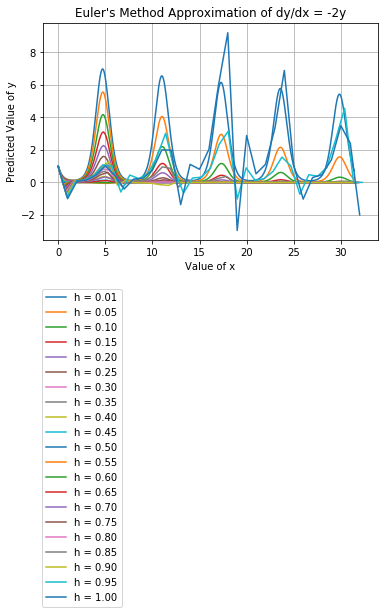

In [9]:
# Euler's Method + Finding average error
for i in range(len(all_h)):
    h = all_h[i]
    X = np.arange(x_start, x_end + h, h)
    Y = np.zeros(len(X))
    Y[0] = 1

    for j in range(len(X) - 1):
        Y[j + 1] = Y[j] + h * function(X[j], Y[j])

    err = np.abs(Y - exact(X))
    average_error[i] = np.mean(err)
    idx_15 = np.argmin(np.abs(X - 15))
    y_values[i] = Y[idx_15]

    plt.plot(X, Y, label=f"h = {h:.2f}") # Plot 1
    
    idx_15 = np.argmin(np.abs(X - 15))
    y_values[i] = Y[idx_15]
    
# Plotting
    
# Plot 1: Compare Euler's method for each value of h
plt.title("Euler's Method Approximation of dy/dx = -2y")
plt.xlabel("Value of x")
plt.ylabel("Predicted Value of y")
plt.legend(bbox_to_anchor = (0.25, -0.2))
# figuring out how to move and format this legend was unironically the hardest part of this homework
plt.grid()
plt.show()

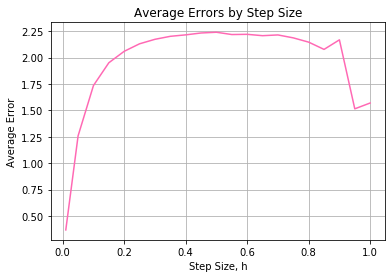

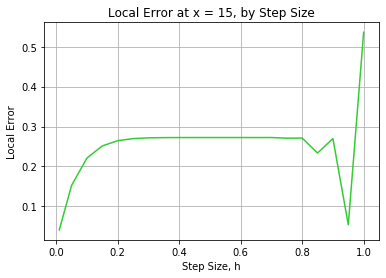

In [10]:
# Plotting continued

# Plot 2: Show the average error between runs, plotting average error vs h
plt.figure()
plt.plot(all_h, average_error, color="hotpink")
plt.title("Average Errors by Step Size")
plt.xlabel("Step Size, h")
plt.ylabel("Average Error")
plt.grid()
plt.show()

# Plot 3: Show the local error at x = 15 for each run, plotting local error vs h
exact_Y_15 = exact(15)
local_error = np.abs(y_values - exact_Y_15)
plt.plot(all_h, local_error, color='limegreen')
plt.title("Local Error at x = 15, by Step Size")
plt.xlabel("Step Size, h")
plt.ylabel("Local Error")
plt.grid()
plt.show()

## Explanation ##
The first graph shows that, for small step sizes, the predicted y-values are closely aligned with the smooth, periodic oscillations of the exact solution, while larger step sizes result in less accurate curves that are less reflective of the function's behavior. The second plot reinforces this by highlighting how average error dramatically increases as step size increases. The downward curve at the end of this graph is due to larger step sizes giving fewer data points, which can deceptively decreases the calculated error when taking averages. This is shown by how, in the third plot, local error fluctuates dramatically around the largest step sizes.

## Addendum ##
A stability analysis on -2y\*cos(x) can be done by comparing it to the constant-coefficient case y' = λy. For y' = -2y, Euler's method is table when h is between 0 and 1, but, in the variable-coefficient equation, λ(x) = -2\*cos(x). It's important to note that this λ changes with the value of x. Because cos(x) oscillates between -1 and 1, λ(x) oscillates between dampening and growth, so no single step size, or h value, greater than zero guarantees stability for all x. As a result, Euler's method is only conditionally stable on intervals where cos(x) is greater than 0. In this case, the stability condition is that 1 must be greater than the absolute value of (1 - (2\*h\*cos(x))). Smaller step sizes reduce instability, but they do not eliminate it.